# Import & Load Data

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
df=pd.read_csv("fertility.csv")
df.head(1)

,Unnamed: 0.1,Unnamed: 0,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,0,0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal


## Q: What is the structure and quality of the dataset?

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Unnamed: 0.1                           99 non-null     int64 
 1   Unnamed: 0                             99 non-null     int64 
 2   Season                                 99 non-null     object
 3   Age                                    99 non-null     int64 
 4   Childish diseases                      99 non-null     object
 5   Accident or serious trauma             99 non-null     object
 6   Surgical intervention                  99 non-null     object
 7   High fevers in the last year           99 non-null     object
 8   Frequency of alcohol consumption       99 non-null     object
 9   Smoking habit                          99 non-null     object
 10  Number of hours spent sitting per day  99 non-null     int64 
 11  Diagnosis            

In [89]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Age,Number of hours spent sitting per day
count,99.000000,99.000000,99.000000,99.000000
mean,49.000000,49.797980,30.111111,10.858586
std,28.722813,29.004919,2.258268,33.782924
min,0.000000,0.000000,27.000000,1.000000
25%,24.500000,25.500000,28.000000,5.000000
50%,49.000000,50.000000,30.000000,7.000000
75%,73.500000,74.500000,32.000000,9.000000
max,98.000000,99.000000,36.000000,342.000000


In [90]:
df.isna().sum()

Unnamed: 0.1                             0
Unnamed: 0                               0
Season                                   0
Age                                      0
Childish diseases                        0
Accident or serious trauma               0
Surgical intervention                    0
High fevers in the last year             0
Frequency of alcohol consumption         0
Smoking habit                            0
Number of hours spent sitting per day    0
Diagnosis                                0
dtype: int64

# Data Cleaning

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Analysis

## Distribution Analysis

# Q: What is the distribution of fertility diagnosis?

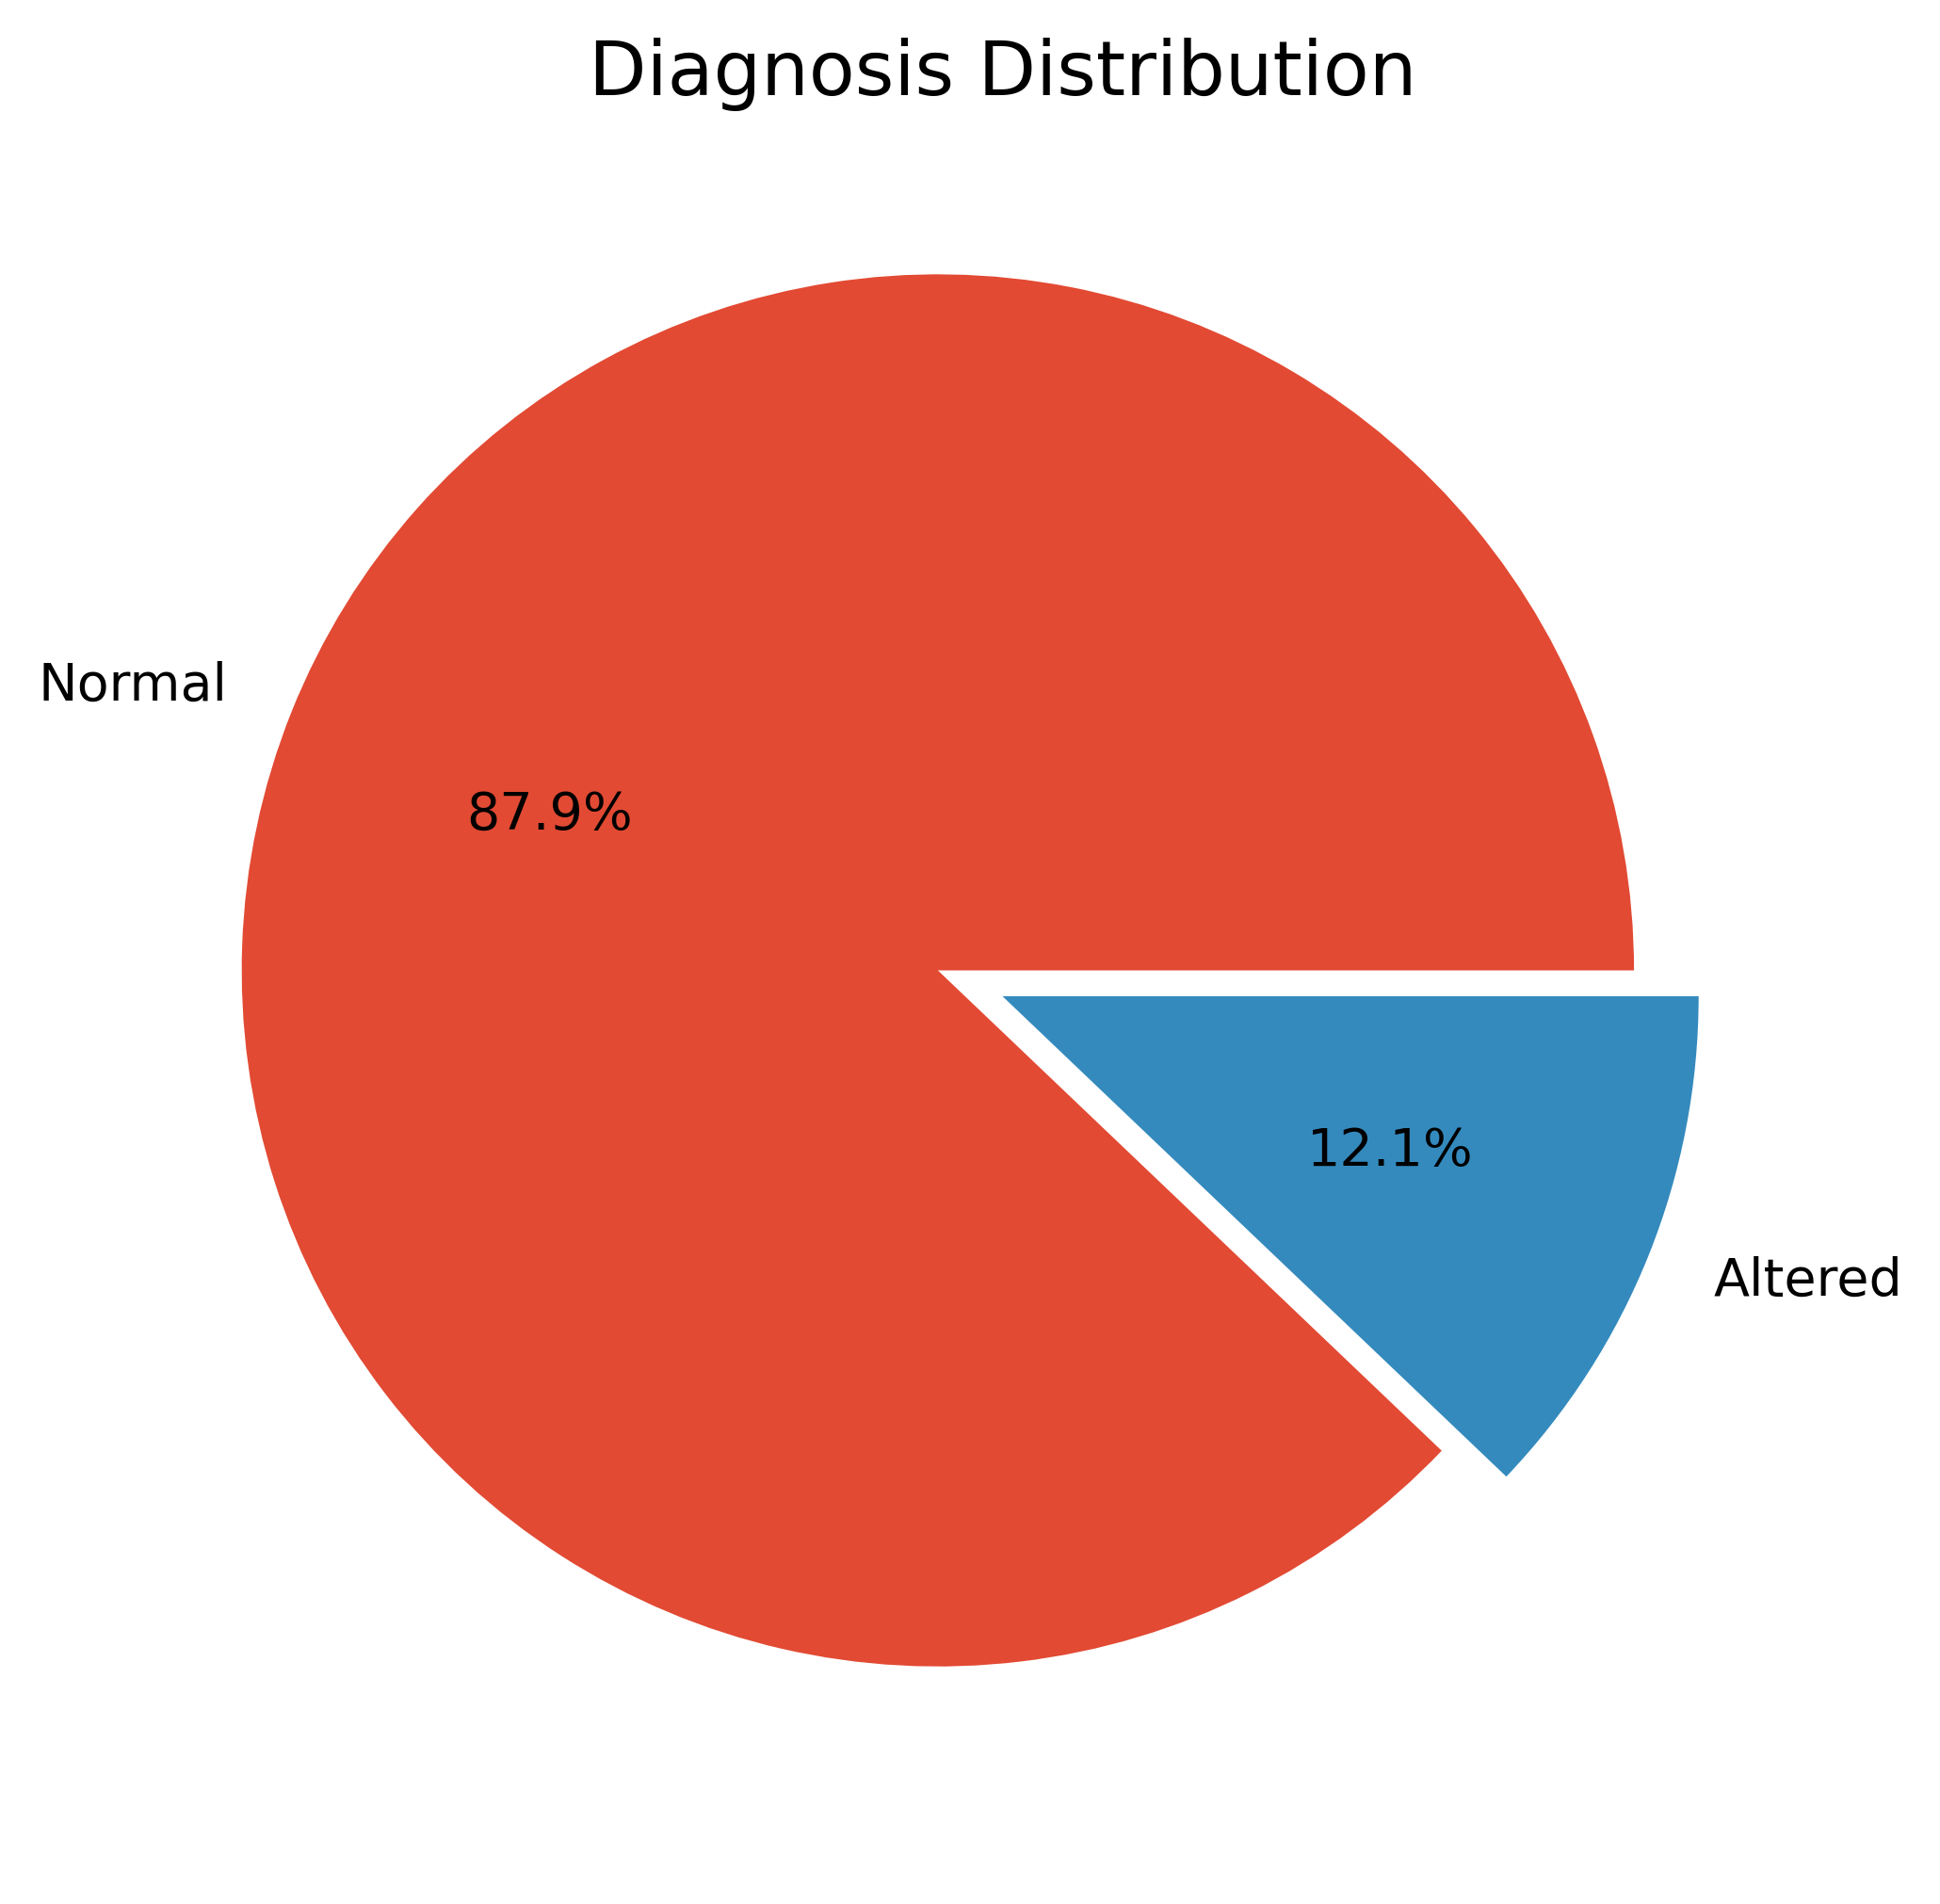

In [93]:
plt.figure(figsize=(12,6),dpi=400)
diagnosis_counts = df['Diagnosis'].value_counts()

plt.pie(diagnosis_counts,labels=diagnosis_counts.index, autopct='%1.1f%%',explode=[0.1,0])

plt.title("Diagnosis Distribution")
plt.show()

# Q: Does age differ across diagnosis groups?

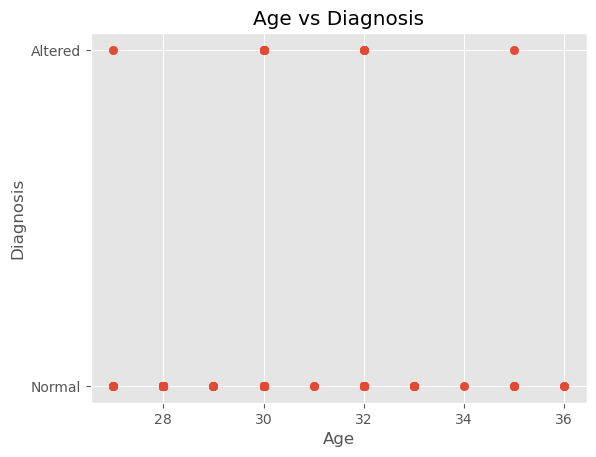

In [94]:
df.groupby('Diagnosis')['Age'].mean()
plt.scatter(df['Age'], df['Diagnosis'])
plt.title("Age vs Diagnosis")
plt.xlabel("Age")
plt.ylabel("Diagnosis")
plt.show()

# Q: How does smoking affect fertility?

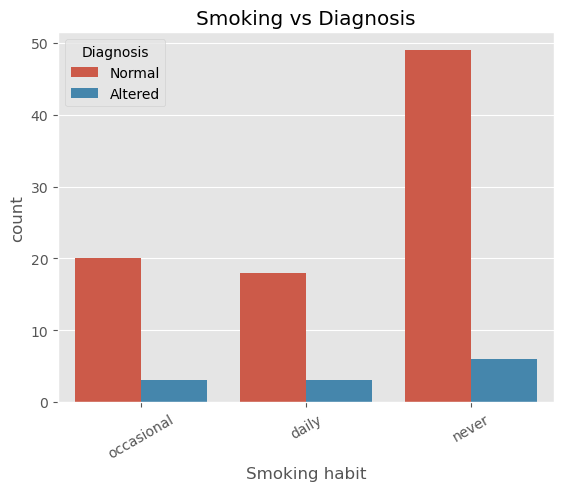

In [95]:
pd.crosstab(df["Smoking habit"],["Diagnosis"])
sns.countplot(x='Smoking habit', hue='Diagnosis', data=df)
plt.title("Smoking vs Diagnosis")
plt.xticks(rotation=30)
plt.show()

# Q: Does alcohol consumption influence fertility?

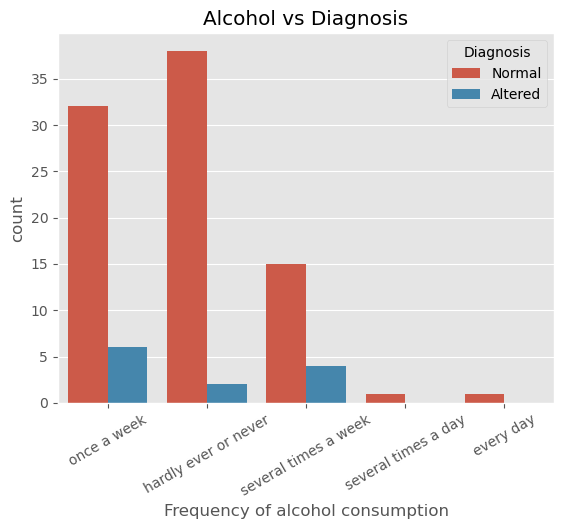

In [96]:
pd.crosstab(df['Frequency of alcohol consumption'],['Diagnosis'])
sns.countplot(x="Frequency of alcohol consumption",hue="Diagnosis",data=df)
plt.title("Alcohol vs Diagnosis")
plt.xticks(rotation=30)
plt.show()

# Q: Does sitting time affect fertility?

In [97]:
df.head(1)

,Unnamed: 0.1,Unnamed: 0,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,0,0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal


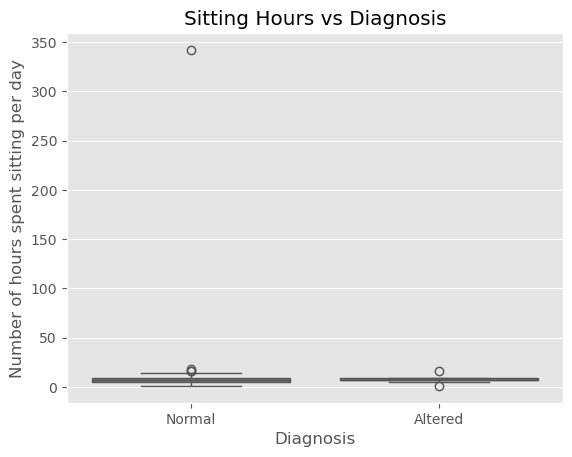

In [98]:
df.groupby('Diagnosis')['Number of hours spent sitting per day'].mean()
sns.boxplot(x='Diagnosis',y='Number of hours spent sitting per day',data=df)
plt.title("Sitting Hours vs Diagnosis")
plt.show()

# Q: Does high fever affect fertility?

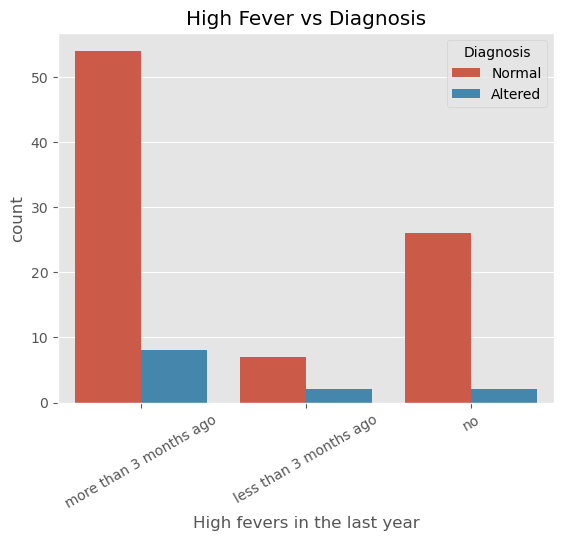

In [99]:
pd.crosstab(df["High fevers in the last year"],["Diagnosis"])
sns.countplot(x="High fevers in the last year",hue="Diagnosis",data=df)
plt.title("High Fever vs Diagnosis")
plt.xticks(rotation=30)
plt.show()

# Q: Does surgery affect fertility?

In [100]:
df.head(1)

,Unnamed: 0.1,Unnamed: 0,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,0,0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal


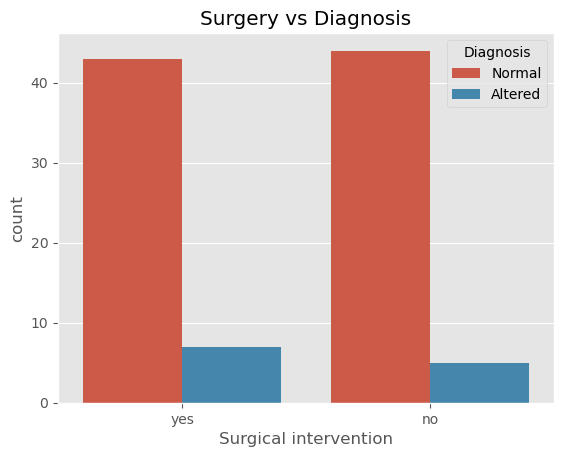

In [101]:
pd.crosstab(df["Surgical intervention"],["Diagnosis"])
sns.countplot(x="Surgical intervention",hue="Diagnosis",data=df)
plt.title("Surgery vs Diagnosis")
plt.show()

# Q: Does trauma affect fertility?

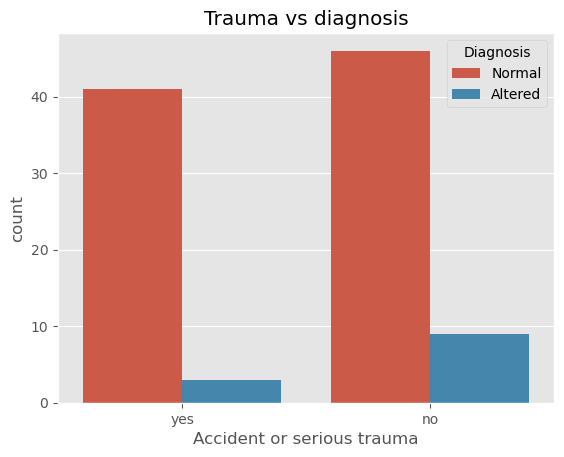

In [102]:
pd.crosstab(df["Accident or serious trauma"],["Diagnosis"])
sns.countplot(x="Accident or serious trauma",hue="Diagnosis",data=df)
plt.title("Trauma vs diagnosis")
plt.show()

# Q: Does season influence fertility?

In [103]:
df.head(1)

,Unnamed: 0.1,Unnamed: 0,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,0,0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal


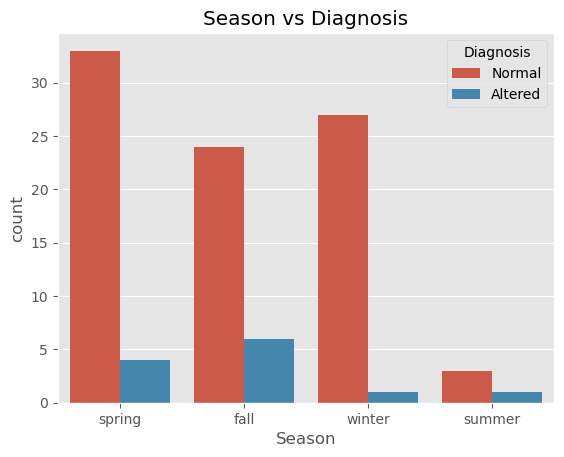

In [104]:
pd.crosstab(df["Season"],["Diagnosis"])
sns.countplot(x="Season",hue="Diagnosis",data=df)
plt.title("Season vs Diagnosis")
plt.show()

In [106]:
df.to_csv("Fertility.csv")